# Word Embeddings

## Text Representations

In machine learning and neural networks, the data often needs to be numerical since models cannot usually work directly with raw text. Text is inherently complex, filled with semantics, context, and structure that computers cannot easily interpret. To train models effectively on textual data, we need systematic ways to convert text into numerical representations while preserving as much relevant information as possible. Without this transformation, machine learning algorithms would be unable to derive patterns or make predictions from text data.

Text is composed of characters and words, which hold meaning for humans but are not directly understandable by machines. To perform tasks like classification, clustering, or generation, machine learning models need features, or numerical inputs, that capture relevant patterns in the text. 

Effective text representations help models understand and make predictions by encoding:
- Frequency and presence of important words
- Context and relationships between words
- Semantic meaning beyond the surface structure

The quality of these representations directly impact model performance.

## Different Approaches To Text Representations

### Bag of Words (BoW)  

The Bag of Words approach is one of the simplest and most widely used text representations. It involves creating a vocabulary from the text and representing each document as a vector indicating the presence or frequency of each word in the vocabulary.

For example, consider two sentences:  
- "The cat sat on the mat."  
- "The dog sat on the mat."  

The vocabulary from these sentences is: `['the', 'cat', 'dog', 'sat', 'on', 'mat']`. 
The first sentence can be represented as a vector: `[2, 1, 0, 1, 1, 1]`, where each entry corresponds to the count of a word from the vocabulary. 

While BoW is easy to implement, it has limitations. Primarily, it ignores word order and the context in which words appear.

![](https://aiml.com/wp-content/uploads/2023/02/disadvantage-bow.png)

#### Example Using CountVectorizer

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample corpus
corpus = [
    "The cat sat on the mat",
    "The dog barked at the cat",
    "The cat chased the mouse",
    "The dog chased the ball"
]

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the corpus into BoW representation
X = vectorizer.fit_transform(corpus)

# Convert the result to a DataFrame for readability
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Display the Bag of Words representation
print("Bag of Words Representation:")
bow_df

Bag of Words Representation:


,at,ball,barked,cat,chased,dog,mat,mouse,on,sat,the
0,0,0,0,1,0,0,1,0,1,1,2
1,1,0,1,1,0,1,0,0,0,0,2
2,0,0,0,1,1,0,0,1,0,0,2
3,0,1,0,0,1,1,0,0,0,0,2


### TF-IDF (Term Frequency-Inverse Document Frequency)  

TF-IDF is a statistical measure used to evaluate how important a word (term) is to a document within a collection or corpus of documents. It builds upon the simple Bag of Words (BoW) representation by incorporating both the frequency of a term in a single document and how common (or rare) that term is across the entire corpus. In other words, TF-IDF helps us down-weight very common words (like “the”, “is”, “and”) that carry little distinguishing information and up-weight rarer and more informative words.

#### Term Frequency (TF)

The term frequency component quantifies how often a given term appears in a specific document. A higher TF value means the term appears more often in that document, suggesting it may be important within that document’s context. There are a few common ways to define TF:

- **Raw Count**:  
  $\mathrm{TF}(t, d) = \text{count of term } t \text{ in document } d.$
  

- **Normalized Frequency** (accounts for document length):  
  $\mathrm{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}.$
  

- **Log-Scaled Frequency** (dampens large counts):  
  $\mathrm{TF}(t, d) =
    \begin{cases}
      1 + \log(\text{count of } t \text{ in } d), & \text{if count} > 0,\\
      0, & \text{otherwise}.
    \end{cases}$
    

#### Inverse Document Frequency (IDF)

While TF measures how often a term appears in one document, IDF measures how unique or rare that term is across the entire corpus. Intuitively:

- If a term appears in almost every document (e.g., “the” or “and”), it carries less discriminative power.
- If a term appears in very few documents (e.g., “photosynthesis” in a mixed corpus), it is more informative.

A common definition of IDF is:

$$
\mathrm{IDF}(t, D) \;=\; \log\!\Bigl(\frac{N}{\,|\{d \in D: t \in d\}|\,}\Bigr),
$$  

where:

- $N$ is the total number of documents in the corpus $D$.
- $|\{\,d \in D : t \in d\,\}|$ is the number of documents in which term $t$ appears (the document frequency of $t$).


Some variants add 1 to the denominator (or to the log) to avoid division by zero or negative values:  
$$
\mathrm{IDF}(t, D) = \log\!\Bigl(\frac{1+N}{1 + |\{d: t \in d\}|}\Bigr) + 1.
$$

The higher the IDF, the rarer the term is across documents.

#### Combining TF and IDF

The core idea of TF-IDF is to multiply the two components:

$$
\text{TF-IDF}(t, d, D) \;=\; \text{TF}(t, d) \times \text{IDF}(t, D).
$$

- If a term $t$ occurs frequently in a document $d$ (high TF) but rarely in the rest of the corpus (high IDF), then TF-IDF is large.  
- If a term is common in a document but also common across many documents (low IDF), then TF-IDF remains moderate.  
- If a term is very rare in the specific document (low TF), its TF-IDF is low regardless of its IDF.  

By weighting words this way, we produce a vector representation for each document where each dimension corresponds to a vocabulary term, and the value is the TF-IDF score. These vectors can then be used as features in downstream tasks (classification, clustering, information retrieval, etc.).

#### Limitations of TF-IDF

- **Ignores Word Order**: TF-IDF still treats each term independently and does not capture the sequence or context in which words appear. For example, “dog bites man” and “man bites dog” have the same TF-IDF representation even though their meanings differ.

- **Ignores Word Relationships/Semantics**: Synonyms (“car” vs. “automobile”) will be treated as completely separate dimensions. TF-IDF does not capture semantic similarity between related words.

- **High Dimensionality**: The resulting feature space is as large as the vocabulary size, which can be in the tens or hundreds of thousands. Sparse, high-dimensional feature vectors can be computationally expensive to store and process.

- **Static Across Corpus**: Once you compute IDF, those values remain fixed unless you retrain. In dynamic corpora where documents are continually added, TF-IDF scores can become stale unless recalculated.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Sample corpus
corpus = [
    "The cat sat on the mat",
    "The dog barked at the cat",
    "The cat chased the mouse",
    "The dog chased the ball"
]

# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the corpus into TF-IDF representation
X = vectorizer.fit_transform(corpus)

# Convert the result to a DataFrame for readability
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Display the TF-IDF matrix
print("TF-IDF Representation:")
tfidf_df

TF-IDF Representation:


,at,ball,barked,cat,chased,dog,mat,mouse,on,sat,the
0,0.000000,0.000000,0.000000,0.301002,0.000000,0.000000,0.471578,0.000000,0.471578,0.471578,0.492178
1,0.492768,0.000000,0.492768,0.314527,0.000000,0.388504,0.000000,0.000000,0.000000,0.000000,0.514293
2,0.000000,0.000000,0.000000,0.361459,0.446473,0.000000,0.000000,0.566295,0.000000,0.000000,0.591032
3,0.000000,0.547794,0.000000,0.000000,0.431887,0.431887,0.000000,0.000000,0.000000,0.000000,0.571724


## Word Embeddings  

Word embeddings are a type of dense vector representation where words with similar meanings have similar vector representations. Instead of treating words as discrete entities, embeddings place them in a continuous vector space, allowing models to capture semantic relationships and contextual similarity. 

For instance, in a well-trained word embedding model, the relationship "king - man + woman" could approximate the vector for "queen," showing how embeddings can encode relational knowledge.

Word embeddings are typically generated by training on large corpora of text. The model learns to place words in the vector space such that words that appear in similar contexts have similar vector representations. The training process focuses on capturing semantic relationships and dependencies between words.

Popular methods for generating word embeddings include **Word2Vec**, **GloVe**, and **FastText**. These models learn from large corpora and capture relationships between words, such as analogies and semantic similarities.

Word embeddings overcome many limitations of simpler methods like BoW and TF-IDF by capturing semantic meaning and some degree of context.

## Word2Vec  

Word2Vec is a popular algorithm for generating word embeddings. Word2Vec uses neural networks to map words into a continuous vector space based on their context in a corpus of text. The key idea is that words appearing in similar contexts will have similar vector representations.  

The training objective of Word2Vec is to predict either:
- the surrounding words given a target word (Skip-Gram) 
- or predict the target word given its surrounding words (CBOW). 
  
**Skip-Gram:**
- The model looks at a single “center” word and tries to guess which words appear around it in the sentence. For example, if the center word is “dog,” it will learn to predict words like “barks,” “leash,” or “park” if those tend to appear near “dog.”

**CBOW (Continuous Bag of Words):**
- The model does the reverse. It takes a group of words around a blank spot (the context) and tries to predict which word belongs in that position. For instance, seeing “the ___ chased the ball,” it would learn to predict “dog.”

Because it only needs to pay attention to a few words at a time rather than the entire vocabulary, Word2Vec can process really large amounts of text very quickly. The end result is that words with similar meanings or grammar roles (like “run” and “jog,” or “cat” and “kitty”) get mapped to vectors that sit close together in this new numerical space. These vectors then become convenient features for tasks like classifying documents, finding related words, or powering simple search systems.

![](https://miro.medium.com/v2/resize:fit:1200/1*xC6wfTU_zpUlpRlXs5NZ4w.png)

### Skip-Gram Model  

The Skip-Gram model, a core component of Word2Vec, predicts the surrounding context words given a target word. For example, given the word "cat," the model will try to predict nearby words like "the," "sat," or "mat."  

Mathematically, this looks like:  

$$
\text{maximize} \, \sum \log P(\text{context} \mid \text{target})
$$

Skip-Gram is particularly useful for capturing meaningful relationships when the corpus is large, as it can effectively handle rare words. One way to understand Skip-Gram intuitively is to visualize a sliding window moving over the text and predicting the words within the window.

### Continuous Bag of Words (CBOW)  

CBOW is the opposite of the Skip-Gram model. Instead of predicting context words given a target word, it predicts the target word based on its surrounding context. Given a window of words surrounding a target word, the model aims to predict the target word.

Mathematically, this looks like:

$$
\text{maximize} \, \sum \log P(\text{target} \mid \text{context})
$$  

CBOW is generally faster to train than Skip-Gram because it averages the context word vectors to predict the target word. However, it may not perform as well on rare words since it relies heavily on the surrounding context.

### Skip-Gram vs. CBOW: Which One Does Word2Vec Use?

A common point of confusion: **Word2Vec does not use both architectures at
once, and it does not pick one automatically.** Skip-Gram and CBOW are two
*separate, mutually exclusive* model designs:

| Architecture | Predicts... | ...from |
|---|---|---|
| **Skip-Gram** | the context words | a single target word |
| **CBOW** | the target word | the surrounding context words |

**You choose which one** when you create the model, via the `sg`
("skip-gram") parameter:

- `sg=1` &rarr; Skip-Gram
- `sg=0` &rarr; CBOW *(this is gensim's default)*

That choice is fixed for the life of the model. A trained Word2Vec model is
*either* a Skip-Gram model *or* a CBOW model — there is no blending, no
switching, and no per-word selection during training. If you want to compare
the two, you train two separate models (you'll see exactly that in the toy
example below, where one line is commented out).

#### How to choose

- **Skip-Gram** (`sg=1`) — slower to train, but tends to produce better
  embeddings for **rare words** and works well on **smaller corpora**. It
  creates more training examples per sentence (one for each context word
  around the target).
- **CBOW** (`sg=0`) — faster to train and often slightly better for
  **frequent words**, because it averages the context vectors into a single,
  smoother prediction. A reasonable default for **large corpora** where
  training speed matters.

Either way, the *output* is the same kind of thing: one dense vector per
vocabulary word. The two architectures just learn those vectors from opposite
prediction tasks.


### Coding Example

Let's train a Word2Vec model with `gensim`. We start with a *tiny* corpus so
the example runs instantly and you can focus on the API: `Word2Vec(...)` to
train, `.wv[word]` to get a vector, and `.most_similar(...)` / `.similarity(...)`
to compare words.

**Important caveat:** Word2Vec learns from co-occurrence statistics, and five
sentences contain almost none. The similarity scores below will look
essentially random — and that *is* the lesson: embeddings need a *large*
corpus. In the Real-World Example near the end of this notebook we train on
~18,000 documents and the results become genuinely meaningful.


In [ ]:
!pip install gensim

In [5]:
from gensim.models import Word2Vec

# A tiny corpus (list of tokenized sentences) — just enough to show the API.
corpus = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "barked", "at", "the", "cat"],
    ["the", "dog", "chased", "the", "ball"],
    ["the", "cat", "chased", "the", "mouse"],
    ["the", "dog", "sat", "on", "the", "sofa"],
]

# Train a Skip-Gram model (sg=1). Use sg=0 for CBOW.
model = Word2Vec(sentences=corpus, vector_size=50, window=3,
                 min_count=1, sg=1, epochs=100)

# Access the learned vector for a word.
print(f"Vector for 'cat' (first 5 of 50 dims): {model.wv['cat'][:5]}")

# Nearest neighbors and a pairwise similarity.
print(f"\nMost similar to 'cat': {model.wv.most_similar('cat', topn=3)}")
print(f"Similarity 'cat' ~ 'dog': {model.wv.similarity('cat', 'dog'):.2f}")

print("\nNote: this corpus has only five sentences, so the scores above are "
      "essentially\nrandom. Word2Vec needs a large corpus — see the "
      "Real-World Example below.")


Vector for 'cat' (first 5 of 50 dims): [-0.017551    0.00739897  0.01054541  0.01177877  0.0147996 ]

Most similar to 'cat': [('on', 0.17365524172782898), ('mat', 0.17027075588703156), ('the', 0.16929365694522858)]
Similarity 'cat' ~ 'dog': 0.04

Note: this corpus has only five sentences, so the scores above are essentially
random. Word2Vec needs a large corpus — see the Real-World Example below.


#### Explanation of Parameters:

- **`sentences`**: The corpus of tokenized sentences used for training.  
- **`vector_size=50`**: The size (dimensionality) of the word embeddings.  
- **`window=3`**: The context window size, meaning the model looks at 3 words before and after the target word.  
- **`min_count=1`**: Minimum number of occurrences for a word to be included in the vocabulary.  
- **`sg=1`**: Skip-Gram model (set `sg=0` for CBOW).  
- **`epochs=100`**: Number of training epochs (iterations over the corpus).  


## Alternatives to Word2Vec  

Although Word2Vec is widely used, several alternative methods exist that address some of its limitations or take different approaches to learning word representations. In this section, we will explore two important alternatives:

- **GloVe (Global Vectors for Word Representation):** A method that leverages global co-occurrence statistics rather than local context windows.
- **BERT and Contextual Embeddings:** Models that generate dynamic word representations based on the surrounding context, allowing the same word to have different embeddings depending on usage.

### GloVe (Global Vectors for Word Representation)

GloVe is an unsupervised learning algorithm developed by Stanford researchers that generates word embeddings by leveraging global word-word co-occurrence statistics from a corpus. Unlike Word2Vec, which learns embeddings by predicting context words from a sliding window, GloVe constructs a large co-occurrence matrix that captures how frequently words appear together across the entire corpus.

#### How GloVe Works

1. **Co-occurrence Matrix:** GloVe first builds a matrix $X$ where each entry $X_{ij}$ represents how often word $i$ appears in the context of word $j$ across the entire corpus.

2. **Weighted Least Squares Objective:** The model then learns word vectors by minimizing a weighted least squares objective that tries to encode the relationship between co-occurrence probabilities:

$$
J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

Where:
- $w_i$ and $\tilde{w}_j$ are word vectors for words $i$ and $j$
- $b_i$ and $\tilde{b}_j$ are bias terms
- $f(X_{ij})$ is a weighting function that prevents very frequent co-occurrences from dominating the objective

3. **Final Embeddings:** The final word embedding for a word is typically the sum of its $w$ and $\tilde{w}$ vectors.

#### Key Differences from Word2Vec

| Aspect | Word2Vec | GloVe |
|--------|----------|-------|
| Training approach | Predictive (neural network) | Count-based (matrix factorization) |
| Context | Local (sliding window) | Global (entire corpus statistics) |
| Objective | Predict context/target words | Reconstruct co-occurrence log-probabilities |

#### Advantages of GloVe
- Efficiently leverages global statistical information
- Often produces high-quality embeddings with less training time on large corpora
- Better at capturing global semantic relationships

#### Coding Example

We will use pre-trained GloVe vectors, which are commonly available and widely used in practice. The `gensim` library provides an easy way to load and work with these embeddings.

In [6]:
import gensim.downloader as api

# Load pre-trained GloVe vectors (this may take a moment to download)
# glove-wiki-gigaword-100 contains 100-dimensional vectors trained on Wikipedia and Gigaword
glove_model = api.load("glove-wiki-gigaword-100")

# Access the vector for a word
cat_vector = glove_model["cat"]
print(f"Vector for 'cat' (first 10 dimensions):\n{cat_vector[:10]}")
print(f"\nVector dimensionality: {len(cat_vector)}")

Vector for 'cat' (first 10 dimensions):
[ 0.23088   0.28283   0.6318   -0.59411  -0.58599   0.63255   0.24402
 -0.14108   0.060815 -0.7898  ]

Vector dimensionality: 100


In [7]:
# Find the most similar words to 'computer'
similar_words = glove_model.most_similar("computer", topn=5)
print("Most similar words to 'computer':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Most similar words to 'computer':
computers: 0.8752
software: 0.8373
technology: 0.7642
pc: 0.7366
hardware: 0.7290


In [8]:
# Word analogies: king - man + woman = ?
# GloVe embeddings capture semantic relationships that allow for analogy reasoning
result = glove_model.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
print("king - man + woman = ?")
for word, similarity in result:
    print(f"{word}: {similarity:.4f}")

king - man + woman = ?
queen: 0.7699
monarch: 0.6843
throne: 0.6756


In [9]:
# Calculate similarity between two words
similarity_score = glove_model.similarity("computer", "software")
print(f"Similarity between 'computer' and 'software': {similarity_score:.4f}")

# Compare with unrelated words
similarity_score_unrelated = glove_model.similarity("computer", "banana")
print(f"Similarity between 'computer' and 'banana': {similarity_score_unrelated:.4f}")

Similarity between 'computer' and 'software': 0.8373
Similarity between 'computer' and 'banana': 0.1213


### BERT and Contextual Embeddings

Unlike Word2Vec and GloVe, which produce **static embeddings** (the same vector for a word regardless of context), **BERT (Bidirectional Encoder Representations from Transformers)** generates **contextual embeddings**. This means the same word can have different vector representations depending on its surrounding words.

For example, consider the word "bank":
- "I deposited money at the **bank**" (financial institution)
- "I sat by the river **bank**" (edge of a river)

With static embeddings, "bank" would have a single vector. With BERT, "bank" gets different embeddings in each sentence, capturing its distinct meanings.

#### Key Differences from Static Embeddings

| Aspect | Static Embeddings (Word2Vec, GloVe) | Contextual Embeddings (BERT) |
|--------|-------------------------------------|------------------------------|
| Word representation | One vector per word | Different vectors based on context |
| Polysemy handling | Single representation for all meanings | Distinct representations for different meanings |
| Computational cost | Low (lookup table) | High (forward pass through model) |

We will explore the Transformer architecture that powers BERT in more detail later in this course. For now, let's see how to use BERT to generate contextual embeddings.

#### Coding Example

In [ ]:
!pip install transformers torch

In [10]:
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
import torch

# Silence the harmless "weights not used" notice from loading a base model.
hf_logging.set_verbosity_error()

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

# Example: get contextual embeddings for every token in a sentence.
sentence = "The cat sat on the mat"
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"Tokens: {tokens}")

with torch.no_grad():
    outputs = model(**inputs)

# last_hidden_state shape: (batch_size, sequence_length, hidden_size=768)
embeddings = outputs.last_hidden_state
print(f"Embedding shape: {tuple(embeddings.shape)}")

cat_idx = tokens.index("cat")
print(f"\nEmbedding for 'cat' (first 10 of 768 dims):\n{embeddings[0, cat_idx, :10]}")


/opt/anaconda3/envs/Teaching-TensorFlow/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████| 199/199 [00:00<00:00, 11452.61it/s]


Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
Embedding shape: (1, 8, 768)

Embedding for 'cat' (first 10 of 768 dims):
tensor([-0.3106, -0.0439,  0.2795, -0.1275,  0.5369,  0.0781,  0.2070,  0.4593,
         0.2091, -0.3197])


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

def get_word_embedding(sentence, word):
    """Return BERT's contextual embedding for `word` as used in `sentence`."""
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    word_index = tokens.index(word.lower())
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0, word_index, :].numpy()

# The word "bank" across three sentences — two financial, one geographic.
s_finance_1 = "I deposited money at the bank"
s_finance_2 = "I withdrew cash from the bank"
s_river     = "I sat by the river bank"

emb_finance_1 = get_word_embedding(s_finance_1, "bank")
emb_finance_2 = get_word_embedding(s_finance_2, "bank")
emb_river     = get_word_embedding(s_river, "bank")

same_sense = cosine_similarity([emb_finance_1], [emb_finance_2])[0][0]
diff_sense = cosine_similarity([emb_finance_1], [emb_river])[0][0]

print("Cosine similarity between BERT embeddings of 'bank':")
print(f"  same sense      (finance vs finance): {same_sense:.4f}")
print(f"  different sense (finance vs river):    {diff_sense:.4f}")


Cosine similarity between BERT embeddings of 'bank':
  same sense      (finance vs finance): 0.9458
  different sense (finance vs river):    0.7393


**What this shows.** Both numbers are fairly high — any two embeddings of the
same token share a lot of general structure, so we should not read a single
score in isolation. What matters is the *relative* comparison: the two
financial uses of "bank" are measurably closer to each other than either is to
the river-bank use.

A static embedding (Word2Vec, GloVe) cannot make this distinction at all — it
has exactly **one** vector for "bank" regardless of context. Producing a
different vector per context is the defining feature of contextual embeddings,
and it is what lets BERT disambiguate polysemous words.


## Important Things to Consider  

#### Window Size  
The window size defines the number of words around a target word that the model should consider when learning embeddings. A shorter window (e.g., 2-3 words) typically captures **syntactic** information, such as word order or grammatical relationships. A longer window (e.g., 5-10 words) is better for capturing **semantic or topical relationships** between words.  

For example:  
- A shorter window size may learn that "run" and "ran" have similar grammatical functions. 
- A longer window size may capture that "book" and "novel" are topically related, even if they are not grammatically similar.  
  
#### Subword Information  
Languages with complex morphology or compound words benefit from embeddings that capture subword information. Techniques like FastText and character-based embeddings decompose words into smaller units, enabling models to handle unseen or rare words more effectively.  
#### Handling Out-of-Vocabulary (OOV) Words  
Static embeddings, such as Word2Vec or GloVe, suffer from the issue of out-of-vocabulary (OOV) words. If a word is not in the training corpus, it will not have an embedding. Contextual embeddings and subword-based models provide solutions to this problem by dynamically generating embeddings or breaking words into subunits.  

#### Semantic and Syntactic Trade-offs  
Depending on the task, you may need embeddings that prioritize semantic relationships (e.g., grouping words by topic) or syntactic relationships (e.g., grammatical roles). Tuning parameters like window size, corpus size, and embedding dimensions allows for optimizing the model based on your needs.

#### Dimensionality and Training Time  
Choosing the dimensionality of the word vectors is important. Larger dimensions generally result in better performance but increase computational cost and risk overfitting. Practical implementations balance the quality of embeddings with the available computational resources.  

## Distance Functions

When we represent text as vectors in an **n-dimensional space**, comparing the similarity between different text representations involves calculating the "distance" between them. 

These distances provide a quantitative measure of how similar (or different) two text samples are, which is crucial for tasks like document clustering, classification, and information retrieval.

The choice of distance function can impact the performance of your model, as different tasks may require different types of similarity measures. 

![](https://www.maartengrootendorst.com/images/posts/2021-01-02-distances/header.png)

### Euclidean Distance

Euclidean distance is one of the most common and straightforward distance metrics. It measures the straight-line distance between two points in space. 

Given two vectors $ \mathbf{A} $ and $ \mathbf{B} $, the Euclidean distance $ d $ is defined as:

$$
d(\mathbf{A}, \mathbf{B}) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}
$$

Intuitively, this works well when comparing vectors based on magnitude or when word order does not matter. However, in high-dimensional spaces or sparse text data, Euclidean distance may not always capture meaningful similarities.

#### Code Example

In [12]:
import numpy as np
from scipy.spatial.distance import euclidean

# Define two vectors (representing text vectors or points in n-dimensional space)
vector1 = np.array([1, 2, 3])
vector2 = np.array([4, 0, 3])

# Method 1: Manual computation of Euclidean distance
euclidean_manual = np.sqrt(np.sum((vector1 - vector2)**2))
print(f"Euclidean distance (manual): {euclidean_manual}")

# Method 2: Using scipy's euclidean function
euclidean_scipy = euclidean(vector1, vector2)
print(f"Euclidean distance (scipy): {euclidean_scipy}")

Euclidean distance (manual): 3.605551275463989
Euclidean distance (scipy): 3.605551275463989


### Manhattan Distance (L1 Distance)

Manhattan distance measures the distance by summing the absolute differences between the vector components. 

Mathematically, it is given by:

$$
d(\mathbf{A}, \mathbf{B}) = \sum_{i=1}^{n} |A_i - B_i|
$$

This metric is useful when movement between dimensions is restricted. It is often used in text-related tasks where small deviations in feature values are meaningful.

#### Code Example

In [13]:
import numpy as np
from scipy.spatial.distance import cityblock  # Scipy function for Manhattan distance

# Define two vectors (representing text vectors or points in n-dimensional space)
vector1 = np.array([1, 2, 3])
vector2 = np.array([4, 0, 3])

# Method 1: Manual computation of Manhattan distance
manhattan_manual = np.sum(np.abs(vector1 - vector2))
print(f"Manhattan distance (manual): {manhattan_manual}")

# Method 2: Using scipy's cityblock function
manhattan_scipy = cityblock(vector1, vector2)
print(f"Manhattan distance (scipy): {manhattan_scipy}")

Manhattan distance (manual): 5
Manhattan distance (scipy): 5


### Minkowski Distance

The **Minkowski distance** is a generalized form of distance that includes both the **Euclidean distance** and **Manhattan distance** as special cases. The formula for the Minkowski distance between two vectors $ \mathbf{A} $ and $ \mathbf{B} $ is:

$$
d(\mathbf{A}, \mathbf{B}) = \left( \sum_{i=1}^{n} |A_i - B_i|^p \right)^{\frac{1}{p}}
$$

- **p = 1:** The formula becomes the **Manhattan distance**.  
- **p = 2:** The formula becomes the **Euclidean distance**.  
- For larger values of $ p $, the metric places more emphasis on large differences between vector components.  

#### Code Example

In [14]:
import numpy as np
from scipy.spatial.distance import minkowski

# Define two vectors (representing text vectors or points in n-dimensional space)
vector1 = np.array([1, 2, 3])
vector2 = np.array([4, 0, 3])

# Method 1: Manual computation of Minkowski distance with p = 3
p = 3
minkowski_manual = np.power(np.sum(np.abs(vector1 - vector2)**p), 1/p)
print(f"Minkowski distance (manual, p=3): {minkowski_manual}")

# Method 2: Using scipy's minkowski function
minkowski_scipy = minkowski(vector1, vector2, p=3)
print(f"Minkowski distance (scipy, p=3): {minkowski_scipy}")

Minkowski distance (manual, p=3): 3.2710663101885897
Minkowski distance (scipy, p=3): 3.2710663101885897


### Cosine Similarity

Cosine similarity is a popular measure for text representations because it compares the **angles between vectors** rather than their magnitudes. This makes it ideal for text data, where two documents with different lengths may still have high similarity if they share the same word distribution.

The formula for cosine similarity between two vectors $ \mathbf{A} $ and $ \mathbf{B} $ is:

$$
\text{cosine similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
$$

Here, $ \mathbf{A} \cdot \mathbf{B} $ represents the dot product of the two vectors, and $ \|\mathbf{A}\| $ and $ \|\mathbf{B}\| $ represent their magnitudes.

Cosine similarity is widely used in **information retrieval** and **document clustering** because it focuses on the direction of vectors, making it less sensitive to differences in vector length.

#### Code Example

In [15]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define two vectors (representing text vectors or points in n-dimensional space)
vector1 = np.array([1, 2, 3])
vector2 = np.array([4, 0, 3])

# Method 1: Manual computation of cosine similarity
dot_product = np.dot(vector1, vector2)
magnitude1 = np.linalg.norm(vector1)
magnitude2 = np.linalg.norm(vector2)
cosine_similarity_manual = dot_product / (magnitude1 * magnitude2)
print(f"Cosine similarity (manual): {cosine_similarity_manual}")

# Method 2: Using scikit-learn's cosine_similarity function
cosine_similarity_sklearn = cosine_similarity([vector1], [vector2])[0][0]
print(f"Cosine similarity (scikit-learn): {cosine_similarity_sklearn}")

Cosine similarity (manual): 0.6948792289723034
Cosine similarity (scikit-learn): 0.6948792289723035


### Other Distance Measures

There are additional distance measures you may encounter depending on the specific problem:

1. **Jaccard Similarity:** Measures the similarity between two sets by dividing the size of their intersection by the size of their union. This is particularly useful for comparing sparse vectors or binary representations of text.
   $$
   J(A, B) = \frac{|A \cap B|}{|A \cup B|}
   $$

2. **Hamming Distance:** Measures the number of positions where corresponding components of two vectors differ. It is commonly used for comparing binary or categorical data.

## Real-World Example: Training Word2Vec on the 20 Newsgroups Corpus

The toy example earlier showed the Word2Vec *API*, but a handful of sentences
can't produce meaningful embeddings. The pre-trained GloVe vectors worked well
because someone trained them on billions of words. Here we do the whole thing
ourselves, end to end, on a real corpus — and watch how much **preprocessing
quality** matters.

The pipeline:

1. **Load and explore** the raw corpus
2. **Preprocess** the messy real-world text
3. **Train** a Word2Vec model
4. **Evaluate** the learned embeddings
5. **Visualize** the embedding space in 2-D

Real text is noisy: email artifacts, punctuation, capitalization, and extremely
common words ("the", "is", "of") that carry no topical signal. Feed that
straight into Word2Vec and the nearest-neighbor results are dominated by junk.
Cleaning the text first is not optional — it is the difference between useful
embeddings and noise.


### Step 1 — Load and Explore the Data

The **20 Newsgroups** dataset is a classic NLP benchmark: roughly 18,000
newsgroup posts spread across 20 topics — everything from `sci.space` and
`comp.graphics` to `rec.sport.hockey` and `talk.politics.mideast`. We strip the
headers, footers, and quoted reply text so the model learns from the message
bodies rather than email metadata.


In [ ]:
!pip install gensim scikit-learn nltk matplotlib

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Load all 20 categories; drop email headers/footers/quoted replies.
newsgroups = fetch_20newsgroups(
    subset="all", remove=("headers", "footers", "quotes")
)

print(f"Documents: {len(newsgroups.data):,}")
print(f"Categories: {len(newsgroups.target_names)}")
for name in newsgroups.target_names:
    print(f"  - {name}")


Documents: 18,846
Categories: 20
  - alt.atheism
  - comp.graphics
  - comp.os.ms-windows.misc
  - comp.sys.ibm.pc.hardware
  - comp.sys.mac.hardware
  - comp.windows.x
  - misc.forsale
  - rec.autos
  - rec.motorcycles
  - rec.sport.baseball
  - rec.sport.hockey
  - sci.crypt
  - sci.electronics
  - sci.med
  - sci.space
  - soc.religion.christian
  - talk.politics.guns
  - talk.politics.mideast
  - talk.politics.misc
  - talk.religion.misc


Sample document  (category: talk.religion.misc)
the blood of the lamb.

This will be a hard task, because most cultures used most animals
for blood sacrifices. It has to be something related to our current
post-modernism state. Hmm, what about used computers?

Cheers,
Kent ...


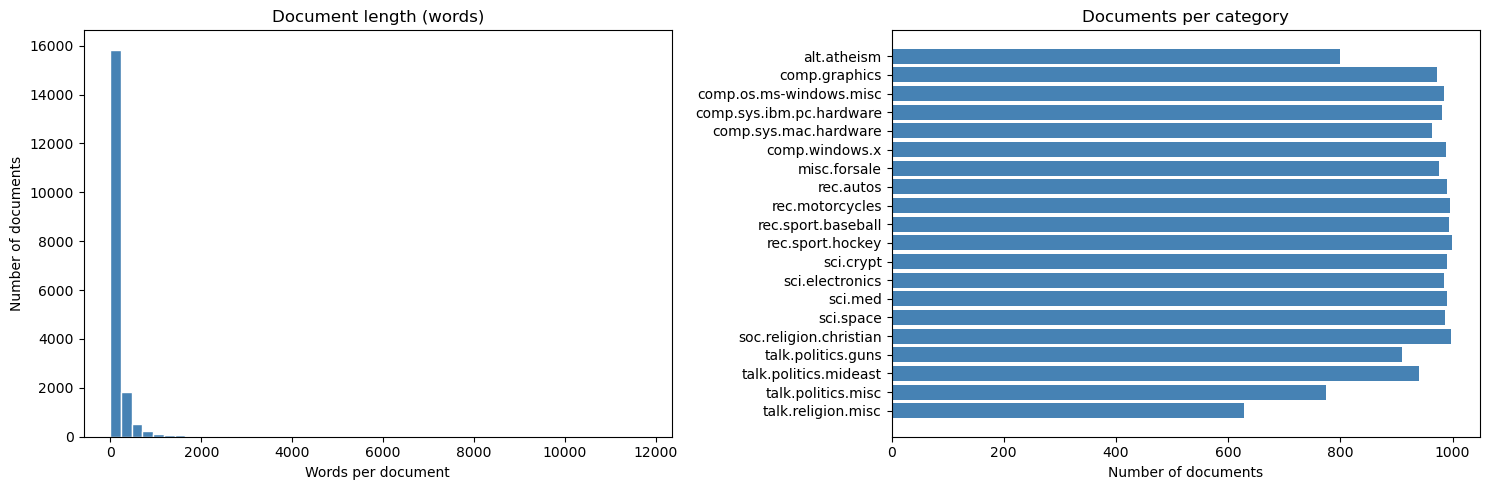


Median document length: 83 words


In [2]:
# A representative document.
sample_idx = 10
print("=" * 70)
print(f"Sample document  (category: {newsgroups.target_names[newsgroups.target[sample_idx]]})")
print("=" * 70)
print(newsgroups.data[sample_idx][:500], "...")

# Distribution of document lengths and documents per category.
doc_word_counts = [len(doc.split()) for doc in newsgroups.data]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(doc_word_counts, bins=50,
             color="steelblue", edgecolor="white")
axes[0].set_title("Document length (words)")
axes[0].set_xlabel("Words per document")
axes[0].set_ylabel("Number of documents")

counts = pd.Series(newsgroups.target).value_counts().sort_index()
axes[1].barh([newsgroups.target_names[i] for i in counts.index], counts.values,
             color="steelblue")
axes[1].set_title("Documents per category")
axes[1].set_xlabel("Number of documents")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nMedian document length: {int(np.median(doc_word_counts))} words")


### Step 2 — Preprocess the Text

Raw newsgroup posts are messy: punctuation, inconsistent capitalization,
email artifacts, and extremely common words ("the", "is", "of") that
co-occur with everything and carry no topical signal. Feeding that straight
into Word2Vec produces noisy embeddings.

Before training, we clean each document with four steps — and each one has a
reason:

| Step | Why |
|------|-----|
| Lowercase | "Computer" and "computer" should be the same token |
| Keep only alphabetic tokens (`[a-z]+`) | Drops numbers, punctuation, and email artifacts |
| Remove stopwords | "the", "is", "of" co-occur with everything — noise, not signal |
| Drop very short tokens (length ≤ 2) | "a", "we", "hi" carry little topical meaning |

Word2Vec learns from *which words keep company with which* — so the cleaner and
more topical the tokens, the sharper the embeddings.


In [3]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

TOKEN_RE = re.compile(r"[a-z]+")

def preprocess(document):
    """Lowercase, keep alphabetic tokens, drop stopwords and very short words."""
    tokens = TOKEN_RE.findall(document.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

tokenized_docs = [preprocess(doc) for doc in newsgroups.data]

# Drop documents that became (nearly) empty after cleaning.
tokenized_docs = [doc for doc in tokenized_docs if len(doc) >= 10]

total_tokens = sum(len(doc) for doc in tokenized_docs)
vocab = {tok for doc in tokenized_docs for tok in doc}
print(f"Documents kept: {len(tokenized_docs):,}")
print(f"Total tokens:   {total_tokens:,}")
print(f"Unique words:   {len(vocab):,}")


Documents kept: 16,896
Total tokens:   1,757,695
Unique words:   93,227


In [4]:
# See preprocessing in action: raw text vs. cleaned tokens.
raw_doc = newsgroups.data[sample_idx]
print("RAW (first 240 chars):")
print(raw_doc[:240])
print("\nCLEANED TOKENS (first 30):")
print(preprocess(raw_doc)[:30])


RAW (first 240 chars):
the blood of the lamb.

This will be a hard task, because most cultures used most animals
for blood sacrifices. It has to be something related to our current
post-modernism state. Hmm, what about used computers?

Cheers,
Kent

CLEANED TOKENS (first 30):
['blood', 'lamb', 'hard', 'task', 'cultures', 'used', 'animals', 'blood', 'sacrifices', 'something', 'related', 'current', 'post', 'modernism', 'state', 'hmm', 'used', 'computers', 'cheers', 'kent']


### Step 3 — Train the Word2Vec Model

Now we train a Skip-Gram model on the cleaned corpus. A few parameter choices
worth noting:

- **`vector_size=100`** — 100-dimensional embeddings, a common default.
- **`window=5`** — looks 5 words to each side; wide enough for topical context.
- **`min_count=10`** — ignore words appearing fewer than 10 times. This drops
  rare junk tokens (misspellings, one-off strings) that would otherwise
  clutter the nearest-neighbor lists.
- **`sg=1`** — Skip-Gram (predict context from target), which tends to do
  better on smaller corpora and rarer words than CBOW.
- **`epochs=20`** — 18k documents is modest, so we make several passes.


In [5]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,
    window=5,
    min_count=10,
    sg=1,
    epochs=20,
    workers=4,
    seed=42,
)

print(f"Vocabulary size:     {len(w2v_model.wv):,} words")
print(f"Embedding dimensions: {w2v_model.wv.vector_size}")


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size:     15,975 words
Embedding dimensions: 100


### Step 4 — Evaluate the Embeddings

The real test: do words that are *topically* related end up close together?
We trained on only ~18k documents (versus billions of tokens for the
pre-trained GloVe vectors earlier), so don't expect perfection — but the
neighbors should be clearly sensible and topically coherent.


In [6]:
# Nearest neighbors for words drawn from several newsgroup topics.
probe_words = ["computer", "space", "hockey", "god", "car", "encryption"]

for word in probe_words:
    if word in w2v_model.wv:
        neighbors = w2v_model.wv.most_similar(word, topn=6)
        formatted = ", ".join(f"{w} ({s:.2f})" for w, s in neighbors)
        print(f"{word:12s} -> {formatted}")
    else:
        print(f"{word:12s} -> (not in vocabulary)")


computer     -> visualisation (0.70), itti (0.68), graphics (0.62), computers (0.61), computing (0.59), conferencing (0.58)
space        -> kjenks (0.71), aeronautics (0.67), shuttle (0.67), gothamcity (0.66), jsc (0.66), jenks (0.63)
hockey       -> nhl (0.75), basketball (0.72), playoff (0.71), ncaa (0.71), teams (0.67), tournament (0.67)
god          -> christ (0.77), jesus (0.77), subsistence (0.75), impersonal (0.75), incarnate (0.75), thessalonians (0.74)
car          -> cars (0.75), nissan (0.75), sentra (0.73), toyota (0.73), tires (0.72), honda (0.70)
encryption   -> nea (0.67), decryption (0.66), crypto (0.66), diffie (0.65), scheme (0.64), telephony (0.64)


In [7]:
# Cosine similarity for related vs. unrelated word pairs.
pairs = [
    ("computer", "software"),   # related
    ("space", "nasa"),          # related
    ("car", "engine"),          # related
    ("computer", "hockey"),     # unrelated
    ("god", "engine"),          # unrelated
]

print("Cosine similarity between word pairs:")
for a, b in pairs:
    if a in w2v_model.wv and b in w2v_model.wv:
        print(f"  {a:10s} ~ {b:10s}: {w2v_model.wv.similarity(a, b): .3f}")
    else:
        print(f"  {a:10s} ~ {b:10s}: (out of vocabulary)")


Cosine similarity between word pairs:
  computer   ~ software  :  0.513
  space      ~ nasa      :  0.629
  car        ~ engine    :  0.662
  computer   ~ hockey    :  0.109
  god        ~ engine    :  0.115


### Step 5 — Visualize the Embedding Space

100 dimensions is impossible to look at directly. We'll use **t-SNE** to
project a selection of words down to 2-D. t-SNE tries to keep words that are
close in the original 100-D space close in the 2-D picture, so topical clusters
should become visible.

For each of a few "seed" words we pull its nearest neighbors, then plot them all
— coloring each word by which seed group it came from.


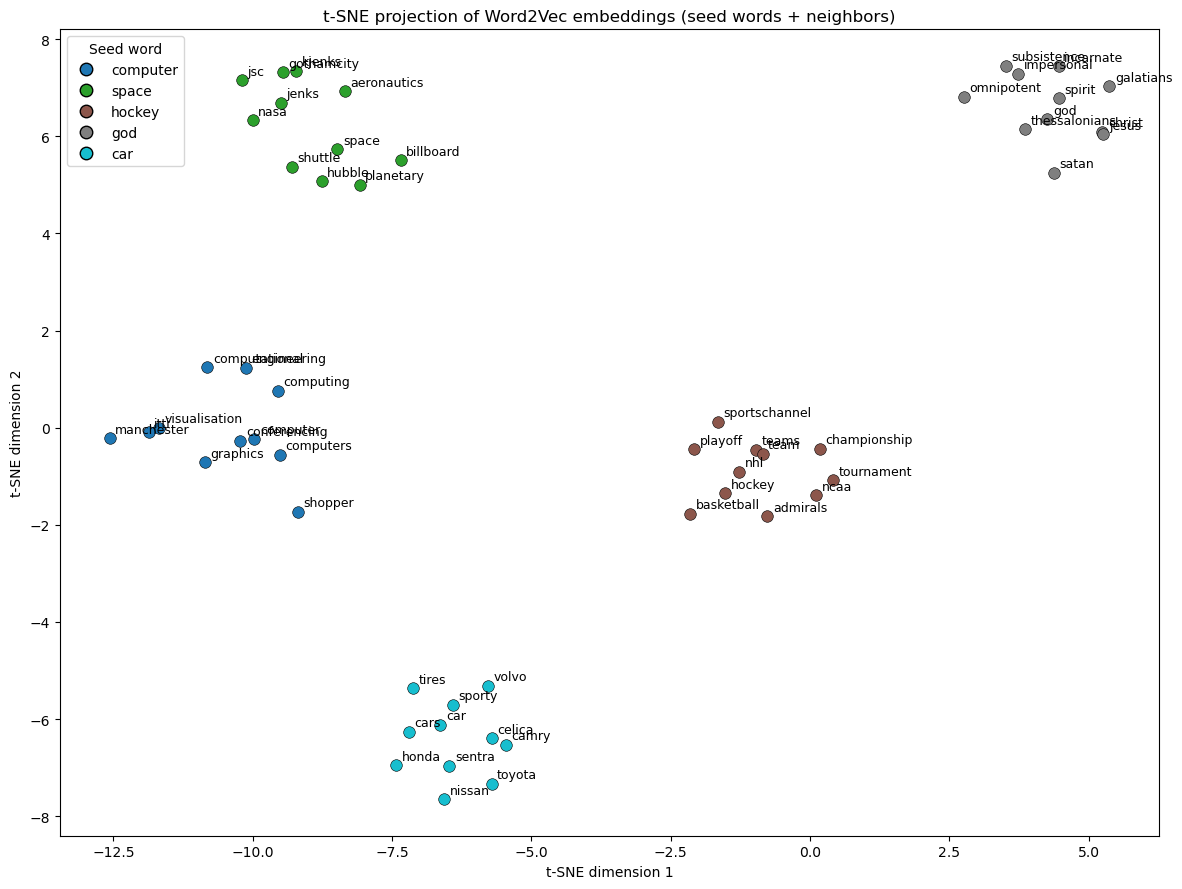

In [8]:
from sklearn.manifold import TSNE

seed_words = ["computer", "space", "hockey", "god", "car"]

# Collect each seed word plus its nearest neighbors.
words, groups = [], []
for seed in seed_words:
    words.append(seed)
    groups.append(seed)
    for neighbor, _ in w2v_model.wv.most_similar(seed, topn=10):
        words.append(neighbor)
        groups.append(seed)

vectors = np.array([w2v_model.wv[w] for w in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=12, init="pca")
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 9))
palette = plt.cm.tab10(np.linspace(0, 1, len(seed_words)))
color_map = {seed: palette[i] for i, seed in enumerate(seed_words)}

for (x, y), word, group in zip(coords, words, groups):
    plt.scatter(x, y, color=color_map[group], s=70,
                edgecolors="black", linewidths=0.4)
    plt.annotate(word, (x, y), fontsize=9,
                 xytext=(4, 4), textcoords="offset points")

handles = [plt.Line2D([0], [0], marker="o", linestyle="",
                       markerfacecolor=color_map[s], markeredgecolor="black",
                       markersize=9, label=s) for s in seed_words]
plt.legend(handles=handles, title="Seed word", loc="best")
plt.title("t-SNE projection of Word2Vec embeddings (seed words + neighbors)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()


### Discussion — What Did We Learn?

- **Preprocessing was decisive.** Word2Vec's output is only as good as the
  tokens it sees — the cleaning step matters as much as any model parameter.
  "Garbage in, garbage out" applies very directly to embeddings.
- **The clusters are real but imperfect.** With ~18k documents the model picks
  up clear topical structure, but you'll still see the occasional odd neighbor.
  The pre-trained GloVe vectors from earlier were trained on *billions* of
  tokens — scale matters enormously for embedding quality.
- **These are still static embeddings.** Every occurrence of a word gets the
  same vector, so a polysemous word like "bank" or "windows" is forced into a
  single compromise representation. That is exactly the limitation that
  contextual models like BERT — covered above — were designed to solve.

**Try it yourself:** swap in different `probe_words` or `seed_words`, change
`min_count` or `window`, or retrain with `sg=0` (CBOW) and compare the
neighbors you get.
